<a href="https://colab.research.google.com/github/vsteurs/testlibrary/blob/master/BigMart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Product-Store Opportunity Score Table (Pivoted)

This table shows the `opportunity_score_per_store` for each `Item_Identifier` (product) across all `Outlet_Identifier`s (stores). Each column corresponds to a specific store, and the 'Total_Opportunity_Score_Across_Stores' provides an aggregate score for each product.

`NaN` values (displayed as blank cells) indicate that the product either doesn't exist in that store or has no sales/visibility data for that combination.

In [108]:
import ipywidgets as widgets
from IPython.display import display, HTML
import numpy as np # Import numpy for NaN handling

# Get the list of columns available for sorting
sort_columns = display_df.columns.tolist()

# Get unique item types for filtering, add 'All' option
item_type_options = ['All'] + sorted(display_df['Item_Type'].unique().tolist())

# Get unique Outlet Location Types for filtering, add 'All' option
# Assuming 'outlet_location_map' or similar has been defined in previous cells
# Use full_product_analysis_per_store_df for this, as it has Outlet_Location_Type
outlet_location_type_options = ['All'] + sorted(full_product_analysis_per_store_df['Outlet_Location_Type'].unique().tolist())

# Get unique Outlet Identifiers for filtering, add 'All' option
outlet_identifier_options = ['All'] + sorted(full_product_analysis_per_store_df['Outlet_Identifier'].unique().tolist())

# Create widgets for column selection, sort order, item type filter, tier filter, and store filter
column_selector = widgets.Dropdown(
    options=sort_columns,
    value='Total Opportunity Score',
    description='Sort by:',
    disabled=False,
)

sort_order_selector = widgets.RadioButtons(
    options=[('Descending', False), ('Ascending', True)],
    value=False,
    description='Order:',
    disabled=False
)

item_type_selector = widgets.Dropdown(
    options=item_type_options,
    value='All',
    description='Filter by Item Type:',
    disabled=False,
)

outlet_location_type_selector = widgets.Dropdown(
    options=outlet_location_type_options,
    value='All',
    description='Filter by Tier:',
    disabled=False,
)

outlet_identifier_selector = widgets.Dropdown(
    options=outlet_identifier_options,
    value='All',
    description='Filter by Store:',
    disabled=False,
)

def sort_and_display_table(column, ascending, item_type_filter, tier_filter, store_filter):
    # Start with a copy of the final_opportunity_analysis_per_store, which contains all product info including global metrics and pivoted scores
    current_filtered_df = final_opportunity_analysis_per_store.copy()

    # Also, create a working copy of the granular data for recalculating metrics based on filters
    metrics_source_df = full_product_analysis_per_store_df.copy()

    # --- Apply Filters to the metrics_source_df and current_filtered_df ---
    # 1. Apply Tier filter
    tier_outlets = []
    if tier_filter != 'All':
        tier_outlets = outlet_location_map[outlet_location_map['Outlet_Location_Type'] == tier_filter].index.tolist()
        metrics_source_df = metrics_source_df[metrics_source_df['Outlet_Identifier'].isin(tier_outlets)]
        # Filter current_filtered_df rows: keep products that have an opportunity score > 0 in any store within the filtered tier
        if tier_outlets:
            current_filtered_df = current_filtered_df[current_filtered_df.apply(lambda row: any(row.get(outlet, 0) > 0 for outlet in tier_outlets), axis=1)]
        else:
            current_filtered_df = current_filtered_df.head(0) # No matching outlets, so empty dataframe

    # 2. Apply Store filter
    if store_filter != 'All':
        metrics_source_df = metrics_source_df[metrics_source_df['Outlet_Identifier'] == store_filter]
        # Filter current_filtered_df rows: keep products that have an opportunity score > 0 in the selected store
        current_filtered_df = current_filtered_df[current_filtered_df[store_filter] > 0]

    # 3. Apply Item Type filter
    if item_type_filter != 'All':
        current_filtered_df = current_filtered_df[current_filtered_df['Item_Type'] == item_type_filter]
        metrics_source_df = metrics_source_df[metrics_source_df['Item_Type'] == item_type_filter]

    # --- Recalculate context-specific 'Sales', 'Ranking', 'Visibility', 'Sales %' and 'Total Opportunity Score' ---
    if not metrics_source_df.empty:
        # Recalculate Sales
        recalculated_sales = metrics_source_df.groupby('Item_Identifier')['total_product_sales_per_store'].sum().reset_index()
        recalculated_sales.rename(columns={'total_product_sales_per_store': 'Sales'}, inplace=True)
        current_filtered_df = pd.merge(current_filtered_df.drop(columns=['Sales']), recalculated_sales, on='Item_Identifier', how='left')

        # Recalculate Ranking based on new Sales
        current_filtered_df['Ranking'] = current_filtered_df['Sales'].rank(method='min', ascending=False)

        # Recalculate Visibility (average of relative_visibility_score_per_store within filtered context)
        recalculated_visibility = metrics_source_df.groupby('Item_Identifier')['relative_visibility_score_per_store'].mean().reset_index()
        recalculated_visibility.rename(columns={'relative_visibility_score_per_store': 'Visibility'}, inplace=True)
        current_filtered_df = pd.merge(current_filtered_df.drop(columns=['Visibility']), recalculated_visibility, on='Item_Identifier', how='left')

        # Recalculate Sales % (average of percentage_of_store_sales_for_product within filtered context)
        recalculated_sales_perc = metrics_source_df.groupby('Item_Identifier')['percentage_of_store_sales_for_product'].mean().reset_index()
        recalculated_sales_perc.rename(columns={'percentage_of_store_sales_for_product': 'Sales %'}, inplace=True)
        current_filtered_df = pd.merge(current_filtered_df.drop(columns=['Sales %']), recalculated_sales_perc, on='Item_Identifier', how='left')

        # Recalculate Total Opportunity Score based on active store/tier filters
        if tier_filter != 'All':
            # Sum only the store columns belonging to the tier
            tier_store_cols = [col for col in current_filtered_df.columns if col.startswith('OUT') and col in tier_outlets]
            current_filtered_df['Total Opportunity Score'] = current_filtered_df[tier_store_cols].sum(axis=1)
        elif store_filter != 'All':
            # If a single store is filtered, Total Opportunity Score is just that store's score
            current_filtered_df['Total Opportunity Score'] = current_filtered_df[store_filter]
        else:
            # If no tier or store filter, sum all OUT columns (it should already be correct from final_opportunity_analysis_per_store, but recalculate to be safe)
            all_out_cols = [col for col in current_filtered_df.columns if col.startswith('OUT')]
            current_filtered_df['Total Opportunity Score'] = current_filtered_df[all_out_cols].sum(axis=1)

    else:
        # If metrics_source_df is empty, set all recalculated columns to default values (e.g., 0 or NaN)
        current_filtered_df['Sales'] = 0
        current_filtered_df['Ranking'] = 0
        current_filtered_df['Visibility'] = np.nan
        current_filtered_df['Sales %'] = 0
        current_filtered_df['Total Opportunity Score'] = 0

    # Fill NaN values in the newly calculated columns that might result from no data for a product in the filtered scope
    current_filtered_df['Sales'] = current_filtered_df['Sales'].fillna(0)
    current_filtered_df['Ranking'] = current_filtered_df['Ranking'].fillna(0) # Or consider dropping rows without sales
    current_filtered_df['Visibility'] = current_filtered_df['Visibility'].fillna(0)
    current_filtered_df['Sales %'] = current_filtered_df['Sales %'].fillna(0)

    # Sort the (potentially updated) current_filtered_df
    # Use na_position='last' to ensure items with 0 sales/scores appear at the end if sorting by these metrics descending
    current_filtered_df = current_filtered_df.sort_values(by=column, ascending=ascending, na_position='last')

    # Build filter description for the title
    filter_desc = []
    if item_type_filter != 'All':
        filter_desc.append(f'Item Type: {item_type_filter}')
    if tier_filter != 'All':
        filter_desc.append(f'Tier: {tier_filter}')
    if store_filter != 'All':
        filter_desc.append(f'Store: {store_filter}')

    filters_applied = ''
    if filter_desc:
        filters_applied = ' - ' + ', '.join(filter_desc)

    # Apply the existing formatting dictionary
    formatted_display = current_filtered_df.head(25).style.format(format_dict_display_df)

    # Display the formatted DataFrame
    display(HTML(f"<h3>Top 25 Products by '{column}' ({'Ascending' if ascending else 'Descending'}{filters_applied})</h3>"))
    display(formatted_display)

# Link the widgets to the display function
interactive_display = widgets.interactive(
    sort_and_display_table,
    column=column_selector,
    ascending=sort_order_selector,
    item_type_filter=item_type_selector,
    tier_filter=outlet_location_type_selector,
    store_filter=outlet_identifier_selector
)

display(interactive_display)

interactive(children=(Dropdown(description='Sort by:', index=16, options=('Item_Identifier', 'Item_Type', 'Sal…

In [129]:
# Calculate the number of stores each product is sold in
store_counts = full_product_analysis_per_store_df.groupby('Item_Identifier')['Outlet_Identifier'].nunique().reset_index()
store_counts.rename(columns={'Outlet_Identifier': 'num_stores_sold_in'}, inplace=True)

# Merge this back to full_product_analysis_all_df
full_product_analysis_all_df = pd.merge(full_product_analysis_all_df, store_counts, on='Item_Identifier', how='left')

# Handle potential division by zero if any product somehow has 0 stores (though unlikely in this dataset)
full_product_analysis_all_df['num_stores_sold_in'] = full_product_analysis_all_df['num_stores_sold_in'].replace(0, 1) # Replace 0 with 1 to avoid ZeroDivisionError, won't affect actual data

# Create a new column for the adjusted opportunity score
full_product_analysis_all_df['opportunity_score_avg_per_store_count'] = full_product_analysis_all_df['opportunity_score'] / full_product_analysis_all_df['num_stores_sold_in']

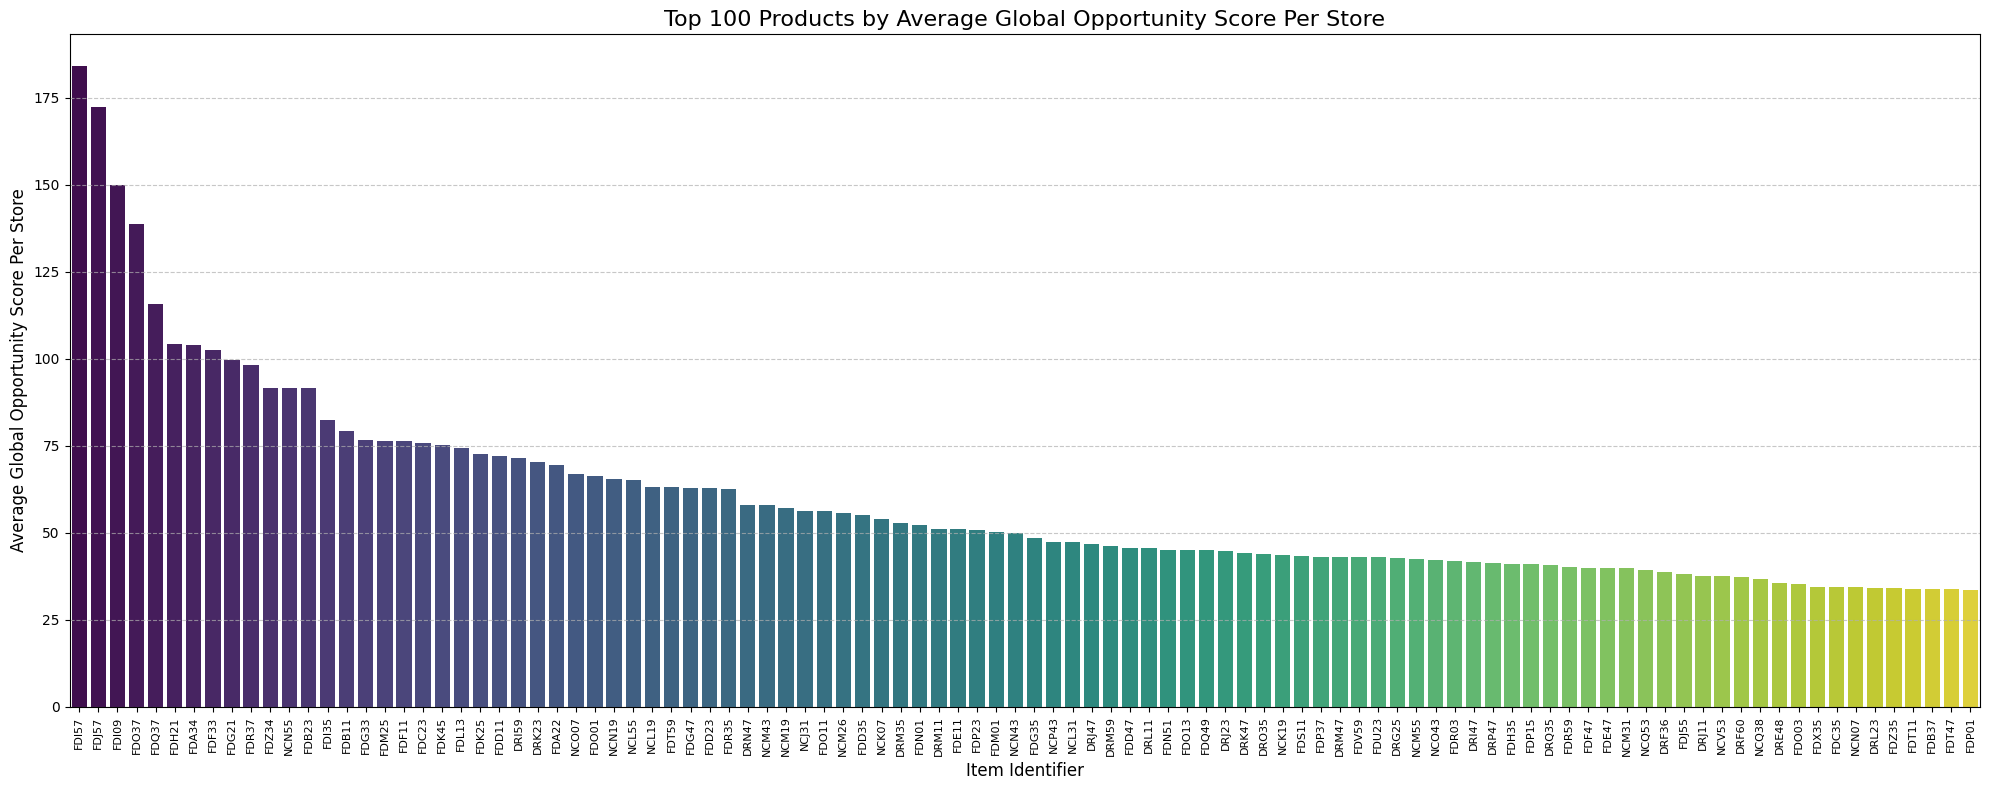

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 100 products ranked by the new adjusted global opportunity score
top_100_products_by_opportunity_adjusted = full_product_analysis_all_df.sort_values(
    by='opportunity_score_avg_per_store_count', ascending=False
).head(100)

# Create the bar chart
plt.figure(figsize=(20, 8))
sns.barplot(
    x='Item_Identifier',
    y='opportunity_score_avg_per_store_count',
    data=top_100_products_by_opportunity_adjusted,
    palette='viridis',
    hue='Item_Identifier', # Assign x to hue to avoid FutureWarning
    legend=False # Hide the legend as it would be redundant for each bar
)
plt.title('Top 100 Products by Average Global Opportunity Score Per Store', fontsize=16)
plt.xlabel('Item Identifier', fontsize=12)
plt.ylabel('Average Global Opportunity Score Per Store', fontsize=12)
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Create a slider for N_products
N_products_slider_sales = widgets.IntSlider(
    value=100,
    min=10,
    max=min(1559, len(full_product_analysis_per_store_df)), # Max N should not exceed total products
    step=10,
    description='Top N Products (by Sales):'
)

def plot_opportunity_by_sales(N_products):
    # Identify all unique store identifiers
    all_store_identifiers = full_product_analysis_per_store_df['Outlet_Identifier'].unique()

    # Dictionary to store the average of opportunity scores for top N selling products per store
    top_N_selling_opportunity_avgs_per_store = {}

    for store_id in all_store_identifiers:
        # Filter for the current store
        store_data = full_product_analysis_per_store_df[
            full_product_analysis_per_store_df['Outlet_Identifier'] == store_id
        ].copy()

        # Sort products by total sales within this store in descending order
        store_data_sorted_by_sales = store_data.sort_values(
            by='total_product_sales_per_store', ascending=False
        )

        # Select the top N products by sales for this store
        top_N_selling_products_for_store = store_data_sorted_by_sales.head(int(N_products))

        # Calculate the average of the opportunity scores of these top N selling products for this store
        avg_of_top_N_selling_scores = top_N_selling_products_for_store['opportunity_score_per_store'].mean()

        # Store the result
        top_N_selling_opportunity_avgs_per_store[store_id] = avg_of_top_N_selling_scores

    # Convert the dictionary to a DataFrame for plotting
    plot_df_selling_products = pd.DataFrame(
        list(top_N_selling_opportunity_avgs_per_store.items()),
        columns=['Store_Identifier', 'Average_of_Top_N_Selling_Products_Opportunity_Scores']
    )

    # Sort the plot_df_selling_products by the average of opportunity scores for better visualization
    plot_df_selling_products = plot_df_selling_products.sort_values(
        by='Average_of_Top_N_Selling_Products_Opportunity_Scores', ascending=False
    )

    # Create the bar chart
    plt.figure(figsize=(12, 7))
    sns.barplot(
        x='Store_Identifier',
        y='Average_of_Top_N_Selling_Products_Opportunity_Scores',
        data=plot_df_selling_products,
        palette='magma', # Another nice sequential palette
        hue='Store_Identifier', # Assign x to hue to avoid FutureWarning
        legend=False # Hide the legend as it would be redundant for each bar
    )

    plt.title(f'Average of Top {N_products} Selling Products\' Opportunity Scores Per Store', fontsize=16)
    plt.xlabel('Store Identifier', fontsize=12)
    plt.ylabel('Average of Top N Selling Products Opportunity Scores', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()

# Display the interactive plot
interactive_plot_sales = widgets.interactive(plot_opportunity_by_sales, N_products=N_products_slider_sales)
display(interactive_plot_sales)

interactive(children=(IntSlider(value=100, description='Top N Products (by Sales):', max=1559, min=10, step=10…

### Average Opportunity Score of Top 10 Products Per Category for OUT010 and OUT019

This visualization shows, for each store ('OUT010' and 'OUT019'), the average opportunity score of its top 10 products within each `Item_Type` (category). This helps identify categories where there are significant opportunities even if the overall store average appears stable.

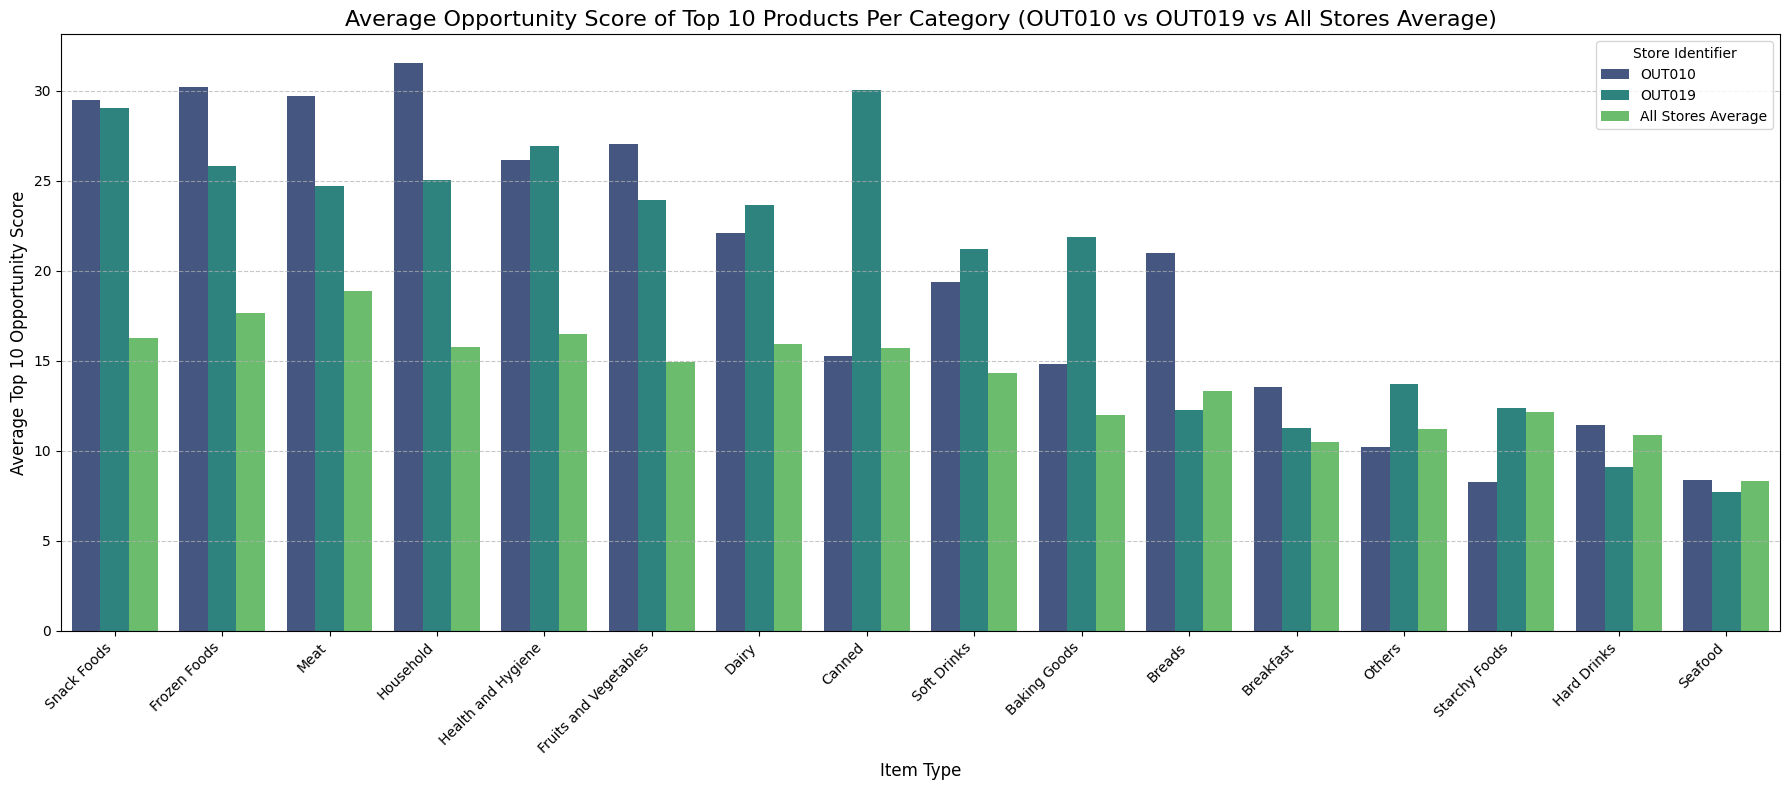

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np # Import numpy for NaN handling

# Define the stores and number of top products to consider
stores_to_analyze = ['OUT010', 'OUT019']
N_products_per_category = 10

# Prepare an empty list to store results for plotting
plot_data = []

for store_id in stores_to_analyze:
    # Filter the main DataFrame to include only relevant columns for the current store
    store_df_relevant = final_opportunity_analysis_per_store[['Item_Identifier', 'Item_Type', store_id]].copy()

    # Group by Item_Type and process each group
    for item_type, group_df in store_df_relevant.groupby('Item_Type'):
        # Sort products within the category by their opportunity score for the current store
        # Filter out 0 scores before sorting to ensure we're getting actual opportunities
        top_products_in_category = group_df[group_df[store_id] > 0].sort_values(by=store_id, ascending=False).head(N_products_per_category)

        if not top_products_in_category.empty:
            avg_opportunity_score = top_products_in_category[store_id].mean()
            plot_data.append({
                'Store_Identifier': store_id,
                'Item_Type': item_type,
                'Average_Top_N_Opportunity_Score': avg_opportunity_score
            })

# Recalculate for 'All Stores' to make it comparable
all_stores_plot_data_new = []

# Assuming 'store_opportunity_columns' is a list of all 'OUTxxx' columns from the kernel state
# store_opportunity_columns is a variable from kernel state (Variable #113)
# It contains: ['OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027', 'OUT035', 'OUT045', 'OUT046', 'OUT049']
for item_type, group_df_all_stores in final_opportunity_analysis_per_store.groupby('Item_Type'):
    # First, identify the top N products globally within this item_type based on their 'Total Opportunity Score'
    # Filter out 0 scores for the 'Total Opportunity Score'
    top_products_global_by_total_score = group_df_all_stores[group_df_all_stores['Total Opportunity Score'] > 0].sort_values(by='Total Opportunity Score', ascending=False).head(N_products_per_category)

    if not top_products_global_by_total_score.empty:
        # Now, for these top N products, calculate their average opportunity score *per store*.
        # We need to consider the individual store scores from the 'OUTxxx' columns.
        # Replace 0s with NaN to exclude stores where the product isn't sold or has no opportunity.
        # Then calculate the mean across the 'OUTxxx' columns for each product, and then average these means.
        # This gives a true 'average per store' for these globally important products.
        individual_store_scores_for_top_N = top_products_global_by_total_score[store_opportunity_columns].replace(0, np.nan)
        average_per_store_per_product = individual_store_scores_for_top_N.mean(axis=1) # Mean score for each product across stores where it has non-zero score

        # Take the mean of these averages to get a single 'All Stores Average' for the category
        avg_opportunity_score_all_stores_comparable = average_per_store_per_product.mean()

        if not np.isnan(avg_opportunity_score_all_stores_comparable):
            all_stores_plot_data_new.append({
                'Store_Identifier': 'All Stores Average', # Clarified label
                'Item_Type': item_type,
                'Average_Top_N_Opportunity_Score': avg_opportunity_score_all_stores_comparable
            })

# Filter out the old 'All Stores' entries and add the new ones
plot_data = [d for d in plot_data if d['Store_Identifier'] not in ['All Stores', 'All Stores Average']]
plot_data.extend(all_stores_plot_data_new)

# Convert the collected data into a DataFrame
plot_df_category_opportunity = pd.DataFrame(plot_data)

# Sort the DataFrame to get the order for plotting (by average score, highest first)
# We need to sort by the average of the average scores for each Item_Type across stores
# Or, more simply, sort by the score itself and let seaborn handle the grouping.
# For a single consistent order, we can average across stores first for the sort key.

# Recompute sort_order after plot_data has been updated
sort_order = plot_df_category_opportunity.groupby('Item_Type')['Average_Top_N_Opportunity_Score'].mean().sort_values(ascending=False).index

# Create the bar charts
plt.figure(figsize=(18, 8))

sns.barplot(
    data=plot_df_category_opportunity,
    x='Item_Type',
    y='Average_Top_N_Opportunity_Score',
    hue='Store_Identifier',
    palette='viridis',
    order=sort_order # Apply the sorted order here
)

plt.title(f'Average Opportunity Score of Top {N_products_per_category} Products Per Category (OUT010 vs OUT019 vs All Stores Average)', fontsize=16)
plt.xlabel('Item Type', fontsize=12)
plt.ylabel(f'Average Top {N_products_per_category} Opportunity Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Store Identifier')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()